# [3장 1강] 다중 회귀와 규제 모델

## 실습 목표

- 다중 선형 회귀로 새로운 학생 생활 특성을 조합한 모델을 구축할 수 있다.
- 특성 공학과 표준화 전처리를 적용하여 입력 데이터를 가공할 수 있다.
- 규제 모델(릿지·라쏘)을 적용하여 과적합 방지 원리를 이해할 수 있다.

## 필수 1: 학생 생활 특성을 활용한 다중 선형 회귀 모델 구현



### 문제 1-1: 독립 변수 다변화 및 기초 회귀 모델 정의

#### 요구 사항

1. 판다스(Pandas) 라이브러리를 사용하여 제공된 `student-por.csv` 데이터를 불러오세요.
2. 독립 변수 `X` 데이터로 과거 낙제 횟수(`failures`), 친구와의 외출 빈도(`goout`), 현재 건강 상태(`health`) 세 가지 컬럼을 선택하세요.
3. 종속 변수 `y` 데이터로 최종 포르투갈어 기말 성적(`G3`) 컬럼을 지정하세요.
4. 규제 강도 `alpha` 파라미터를 0으로 설정한 Ridge 모델을 생성하고 학습시킨 후, 각 독립 변수의 회귀 계수(가중치)와 절편을 출력하세요.

#### 출력 및 검증 방법

작성한 파이썬 코드를 실행하여 모델 학습을 완료하세요. 화면에 각 독립 변수의 이름과 함께 계산된 회귀 계수 및 절편이 출력되는지 확인하세요.

In [13]:
import pandas as pd
from sklearn.linear_model import Ridge
df = pd.read_csv("student-por.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [11]:
X = df [['failures','goout','health']]
y = df['G3']
X.head()

,failures,goout,health
0,0,4,3
1,0,3,3
2,0,2,3
3,0,2,5
4,0,2,5


In [14]:
model = Ridge(alpha=0)
model.fit(X, y)
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")


print(f"intercept: {model.intercept_}")

failures: -2.107656720376336
goout: -0.19660246767929365
health: -0.1925629099990602
intercept: 13.680757699345355


## 필수 2: 다항 특성 확장 및 표준화 전처리 적용

변수 데이터에 특성 공학을 적용하여 다항 특성으로 확장하고, 데이터 단위를 맞춰주는 표준화 작업을 수행합니다.

### 문제 2-1: 고차원 파생 변수 생성 및 StandardScaler 활용

#### 요구 사항

- 문제 1-1에서 불러온 독립 변수 `X` 데이터에 `PolynomialFeatures(degree=2, include_bias=False)`를 적용하여 특성을 확장하세요.
- 특성 공학이 완료된 데이터의 형태(Shape)와 확장된 특성 이름을 화면에 출력하여 확인하세요.
- 변수 간 데이터 단위를 맞춰주기 위해 `StandardScaler`를 생성하고, 확장된 다항 변수 데이터를 표준점수로 변환하세요.

#### 출력 및 검증 방법

다항 변수로 확장된 데이터의 열 개수가 9개인지 확인하세요. 변환된 표준점수 배열의 첫 5개 행 데이터를 출력하세요.

In [16]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(X)

print("데이터:", X_poly.shape)

feature_names = poly.get_feature_names_out(X.columns)

print(feature_names)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)


print(X_scaled[:5])

데이터: (649, 9)
['failures' 'goout' 'health' 'failures^2' 'failures goout'
 'failures health' 'goout^2' 'goout health' 'health^2']
[[-0.37430512  0.69378496 -0.3710422  -0.27717038 -0.3424015  -0.3446603
   0.58782199  0.11749022 -0.59976447]
 [-0.37430512 -0.15738033 -0.3710422  -0.27717038 -0.3424015  -0.3446603
  -0.33144662 -0.34370626 -0.59976447]
 [-0.37430512 -1.00854562 -0.3710422  -0.27717038 -0.3424015  -0.3446603
  -0.98806706 -0.80490273 -0.59976447]
 [-0.37430512 -1.00854562  1.01290255 -0.27717038 -0.3424015  -0.3446603
  -0.98806706 -0.1899741   1.1159254 ]
 [-0.37430512 -1.00854562  1.01290255 -0.27717038 -0.3424015  -0.3446603
  -0.98806706 -0.1899741   1.1159254 ]]


## 심화 1: 릿지와 라쏘 규제 모델의 효과 비교 분석

과적합을 방지하기 위해 규제를 적용하는 릿지(Ridge) 및 라쏘(Lasso) 회귀 모델을 구현하고, 규제 강도에 따른 가중치 변화를 시각화하여 비교합니다.

### 문제 3-1: 하이퍼파라미터 alpha 변화에 따른 계수 축소 시각화

#### 요구 사항

1. 넘파이(NumPy) 라이브러리의 `logspace` 함수를 사용하여 규제 강도 `alpha` 값을 0.001부터 1000까지 200단계로 구성하세요.
2. 생성된 `alpha` 배열을 순회하며 Ridge 모델과 Lasso 모델을 각각 생성하고, 문제 2-1에서 전처리한 데이터를 사용하여 학습시키세요.
3. Lasso 모델의 안정적인 연산을 위해 최대 반복 횟수(`max_iter`)를 20000으로, 수렴 허용 오차(`tol`)를 `1e-4`로 설정하세요.
4. matplotlib 라이브러리를 사용하여 1행 2열 크기의 그래프 영역을 만들고, 왼쪽에는 릿지 모델, 오른쪽에는 라쏘 모델의 회귀 계수 축소 과정을 시각화하세요. x축에는 로그 스케일을 적용하세요.

#### 출력 및 검증 방법

규제 강도가 증가함에 따라 릿지 회귀의 가중치가 완만하게 0으로 수축하는 흐름과, 라쏘 회귀의 가중치가 0으로 떨어지며 특정 변수가 제외되는 특성을 확인하세요.

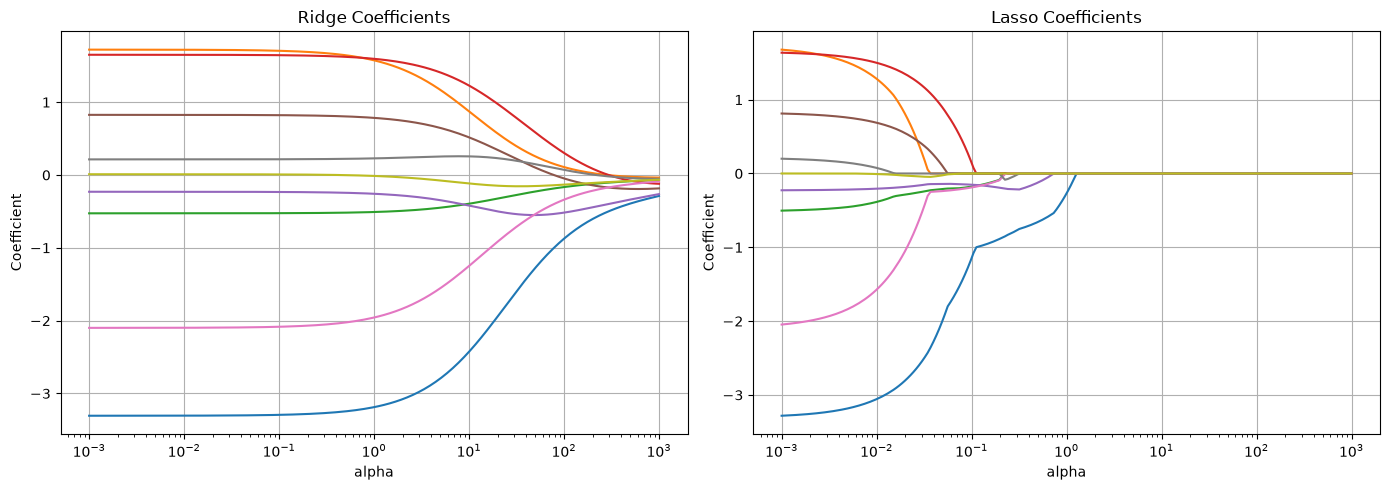

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso

alphas = np.logspace(-3, 3, 200)

ridge_coefs = []
lasso_coefs = []



for alpha in alphas:
    
   
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_scaled, y)
    ridge_coefs.append(ridge.coef_)
    
  
    lasso = Lasso(
        alpha=alpha,
        max_iter=20000,
        tol=1e-4
    )
    lasso.fit(X_scaled, y)
    lasso_coefs.append(lasso.coef_)



ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)



fig, axes = plt.subplots(1, 2, figsize=(14, 5))



axes[0].plot(alphas, ridge_coefs)
axes[0].set_xscale('log')
axes[0].set_xlabel('alpha')
axes[0].set_ylabel('Coefficient')
axes[0].set_title('Ridge Coefficients')
axes[0].grid(True)


axes[1].plot(alphas, lasso_coefs)
axes[1].set_xscale('log')
axes[1].set_xlabel('alpha')
axes[1].set_ylabel('Coefficient')
axes[1].set_title('Lasso Coefficients')
axes[1].grid(True)


plt.tight_layout()
plt.show()